# Phase 1 / Phase 2 Validation Workflow

This notebook is the current checkpoint notebook for the differentiable phase-image inversion plan.

It demonstrates the workflow that is already implemented in the repository:
- differentiable synthetic support and magnetization fields
- forward phase generation from $\rho \cdot m$
- a simple gradient sanity check for the forward path
- the current NeuralMag adapter and energy-backend interfaces

It does **not** yet implement the Phase 3 reconstruction loop. That is the next code target after this validation notebook.

In [7]:
from pathlib import Path
import os
import sys

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.1")
os.environ.setdefault("JAX_ENABLE_X64", "1")

repo_root = Path.cwd().resolve().parents[2]
src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import unxt as u

from libertem_holo.base.mbir import (
    forward_phase_from_density_and_magnetization,
    soft_disc_support,
    vortex_magnetization,
    uniform_magnetization,
    domain_wall_magnetization,
)
from libertem_holo.base.mbir.neuralmag_adapter import neuralmag_state_to_mbir_rho_m
from libertem_holo.base.mbir_energy_backend import NeuralMagEnergyBackend

print(f'Repo root: {repo_root}')
print(f'JAX default backend: {jax.default_backend()}')
print(f'JAX x64 enabled: {jax.config.read("jax_enable_x64")}')

Repo root: /Users/landers/LiberTEM-holo
JAX default backend: gpu
JAX x64 enabled: True


In [2]:
shape = (3, 64, 64)
pixel_size = u.Quantity(1.0, 'nm')

rho = soft_disc_support(shape, radius=18.0, edge_width=1.2)
m_vortex = vortex_magnetization(shape, support_zyx=rho, core_radius=2.0)
m_uniform = uniform_magnetization(shape, support_zyx=rho, direction_xyz=(1.0, 0.0, 0.0))
m_wall = domain_wall_magnetization(shape, support_zyx=rho, wall_width=3.0)

phase_vortex = forward_phase_from_density_and_magnetization(rho, m_vortex, pixel_size, axis='z')
phase_uniform = forward_phase_from_density_and_magnetization(rho, m_uniform, pixel_size, axis='z')
phase_wall = forward_phase_from_density_and_magnetization(rho, m_wall, pixel_size, axis='z')

print('rho shape:', rho.shape)
print('m_vortex shape:', m_vortex.shape)
print('phase_vortex shape:', phase_vortex.shape)

W0420 07:51:31.308912  636911 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning


rho shape: (3, 64, 64)
m_vortex shape: (3, 64, 64, 3)
phase_vortex shape: (64, 64)


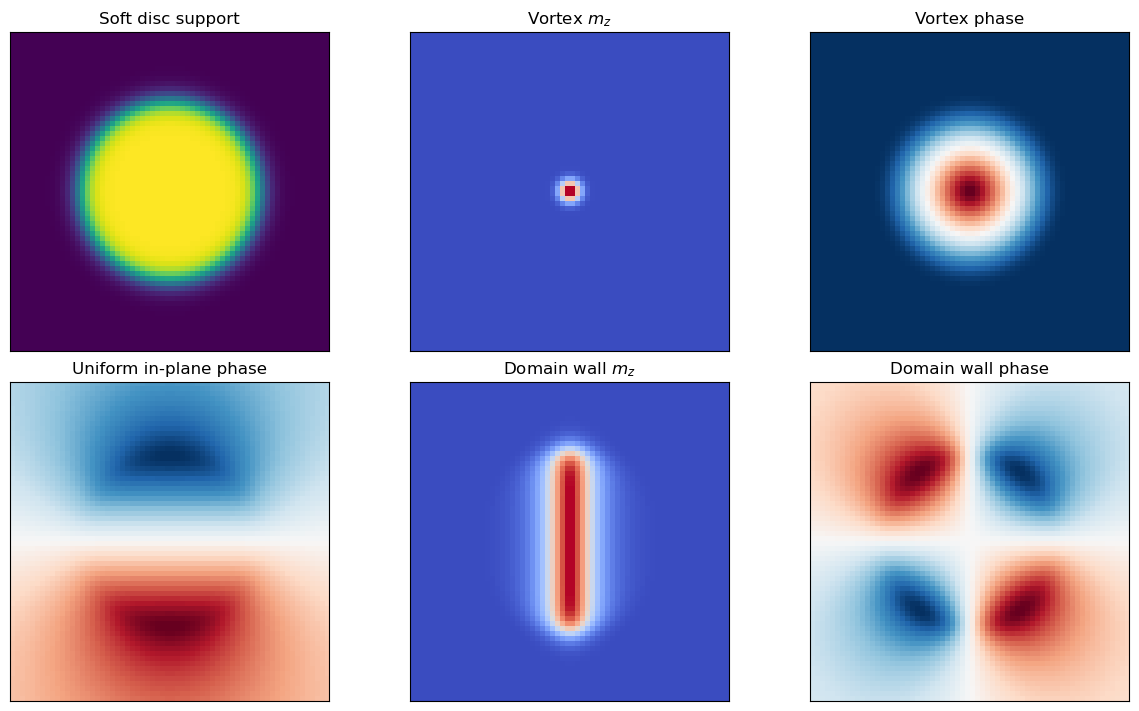

In [3]:
mid_z = shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

axes[0, 0].imshow(np.asarray(rho[mid_z]), cmap='viridis')
axes[0, 0].set_title('Soft disc support')

axes[0, 1].imshow(np.asarray(m_vortex[mid_z, ..., 2]), cmap='coolwarm')
axes[0, 1].set_title('Vortex $m_z$')

axes[0, 2].imshow(np.asarray(phase_vortex), cmap='RdBu_r')
axes[0, 2].set_title('Vortex phase')

axes[1, 0].imshow(np.asarray(phase_uniform), cmap='RdBu_r')
axes[1, 0].set_title('Uniform in-plane phase')

axes[1, 1].imshow(np.asarray(m_wall[mid_z, ..., 2]), cmap='coolwarm')
axes[1, 1].set_title('Domain wall $m_z$')

axes[1, 2].imshow(np.asarray(phase_wall), cmap='RdBu_r')
axes[1, 2].set_title('Domain wall phase')

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

## Gradient sanity check

This reproduces the core Phase 1 differentiability idea: the forward phase is differentiable with respect to the support field.

In [4]:
rho_small = soft_disc_support((2, 20, 20), radius=6.0, edge_width=1.0, dtype=jnp.float64)
m_small = vortex_magnetization((2, 20, 20), support_zyx=rho_small, core_radius=1.5, dtype=jnp.float64)

def phase_energy(rho_arg):
    phase = forward_phase_from_density_and_magnetization(rho_arg, m_small, pixel_size, axis='z')
    return jnp.mean(phase ** 2)

grad_rho = jax.grad(phase_energy)(rho_small)
idx = (0, 10, 13)
eps = 1e-4
perturb = jnp.zeros_like(rho_small).at[idx].set(1.0)
fd = (phase_energy(rho_small + eps * perturb) - phase_energy(rho_small - eps * perturb)) / (2 * eps)

print('grad shape:', grad_rho.shape)
print('all finite:', bool(jnp.all(jnp.isfinite(grad_rho))))
print('autodiff value:', float(grad_rho[idx]))
print('finite-difference value:', float(fd))
print('absolute error:', float(jnp.abs(grad_rho[idx] - fd)))

grad shape: (2, 20, 20)
all finite: True
autodiff value: 9.818831739124513e-08
finite-difference value: 9.81883173874795e-08
absolute error: 3.7656305508068015e-18


## Phase 2 adapter checkpoint

The real NeuralMag ground-truth path is still being stabilized, but the adapter logic is already implemented.

The cell below demonstrates the current adapter on a mock NeuralMag-style tensor with layout $(x, y, z, [\rho, m_x, m_y, m_z])$.

In [5]:
nx, ny, nz = 5, 6, 4
mock_state = np.zeros((nx, ny, nz, 4), dtype=np.float32)
mock_state[..., 0] = 1.0
mock_state[..., 1] = np.linspace(-1.0, 1.0, nx)[:, None, None]
mock_state[..., 2] = np.linspace(-0.5, 0.5, ny)[None, :, None]
mock_state[..., 3] = np.linspace(0.0, 1.0, nz)[None, None, :]

rho_mbir, m_mbir = neuralmag_state_to_mbir_rho_m(mock_state, voxel_size=(2.0, 2.0, 2.0), state_is_nodal=False)

print('converted rho shape:', rho_mbir.shape)
print('converted m shape:', m_mbir.shape)
print('rho min/max:', float(rho_mbir.min()), float(rho_mbir.max()))
print('m component means:', np.mean(m_mbir, axis=(0, 1, 2)))

converted rho shape: (4, 6, 5)
converted m shape: (4, 6, 5, 3)
rho min/max: 1.0 1.0
m component means: [0.  0.  0.5]


In [ ]:
def demo_resolver(term):
    def energy_fn(weighted_m):
        scale = 1.0 if term == 'exchange' else 0.25
        return float(scale * np.linalg.norm(weighted_m))
    return energy_fn

mid_z = rho.shape[0] // 2
backend = NeuralMagEnergyBackend(('exchange', 'demag'), resolver=demo_resolver)
energies = backend.energies(rho=np.asarray(rho[mid_z]), m=np.asarray(m_vortex[mid_z]))
energies

{'exchange': 28.160125732421875, 'demag': 7.040031433105469}

## What this notebook says about the plan

Current status:
- Phase 1 is in good shape: support generation, analytic fields, forward phase, and gradients all exist.
- Phase 2 has the adapter and energy-backend interfaces, but not yet the full stable development workflow for the real NeuralMag vortex path.
- The next real implementation target is **Phase 3 Regime A**: a 3D solver that compares no prior, smoothness, and NeuralMag energy on the same synthetic problem.

So this notebook is the validation handoff: it demonstrates the current baseline before the reconstruction loop is added.